<a href="https://colab.research.google.com/github/sheilasilvacezarano-sys/imersao-dados-python-alura-2026/blob/main/Dados_com_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1 - Análise de Dados com Pandas

In [26]:
import pandas as pd

In [27]:
df = pd.read_csv('https://raw.githubusercontent.com/sheilasilvacezarano-sys/imersao-dados-python-alura-2026/refs/heads/main/dados-imersao-final.csv')

In [28]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133339 entries, 0 to 133338
Data columns (total 12 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   ano              133339 non-null  int64 
 1   senioridade      133339 non-null  object
 2   contrato         133339 non-null  object
 3   cargo            133339 non-null  object
 4   salario          133339 non-null  int64 
 5   moeda            133339 non-null  object
 6   usd              133339 non-null  int64 
 7   residencia       133339 non-null  object
 8   remoto           133339 non-null  object
 9   empresa          133339 non-null  object
 10  tamanho_empresa  133339 non-null  object
 11  residencia_iso3  133337 non-null  object
dtypes: int64(3), object(9)
memory usage: 12.2+ MB


In [30]:
df.describe()

,ano,salario,usd
count,133339.000000,1.333390e+05,133339.000000
mean,2024.358770,1.632846e+05,157619.079339
std,0.680627,2.173937e+05,74289.262933
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060065e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


In [31]:
df.shape

(133339, 12)

In [32]:
linhas, colunas = df.shape[0], df.shape[1]
print('Linhas:', linhas)
print('Colunas:', colunas)

Linhas: 133339
Colunas: 12


In [33]:
df.columns

Index(['ano', 'senioridade', 'contrato', 'cargo', 'salario', 'moeda', 'usd',
       'residencia', 'remoto', 'empresa', 'tamanho_empresa',
       'residencia_iso3'],
      dtype='object')

Renomeando as colunas do DataFrame

In [34]:
# Dicionário de renomeação
novos_nomes = {
    'work_year': 'ano',
    'experience_level': 'senioridade',
    'employment_type': 'contrato',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda',
    'salary_in_usd': 'usd',
    'employee_residence': 'residencia',
    'remote_ratio': 'remoto',
    'company_location': 'empresa',
    'company_size': 'tamanho_empresa'
}

# Aplicando renomeação
df.rename(columns=novos_nomes, inplace=True)

# Verificando resultado
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


Analisando quais são as categorias das colunas categóricas

Nível de senioridade

In [35]:
# O método .value_counts() serve para contar quantas vezes cada valor único aparece em uma coluna.
df['senioridade'].value_counts()


,count
senioridade,
senior,77236
pleno,40462
junior,12441
executivo,3200


Tipo de contrato

In [36]:
df['contrato'].value_counts()

,count
contrato,
integral,132553
contrato,394
parcial,376
freelancer,16


Regime de trabalho

In [37]:
df['remoto'].value_counts()

,count
remoto,
presencial,105305
remoto,27716
hibrido,318


Tamanho da empresa

In [38]:
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
media,129554
grande,3571
pequena,214


Modificando o nome das categorias:

In [39]:
senioridade = {
    'SE': 'senior',
    'MI': 'pleno',
    'EN': 'junior',
    'EX': 'executivo'
}
df['senioridade'] = df['senioridade'].replace(senioridade)
df['senioridade'].value_counts()

,count
senioridade,
senior,77236
pleno,40462
junior,12441
executivo,3200


In [40]:
contrato = {
    'FT': 'integral',
    'PT': 'parcial',
    'CT': 'contrato',
    'FL': 'freelancer'
}
df['contrato'] = df['contrato'].replace(contrato)
df['contrato'].value_counts()

,count
contrato,
integral,132553
contrato,394
parcial,376
freelancer,16


In [41]:
tamanho_empresa = {
    'L': 'grande',
    'S': 'pequena',
    'M':	'media'

}
df['tamanho_empresa'] = df['tamanho_empresa'].replace(tamanho_empresa)
df['tamanho_empresa'].value_counts()

,count
tamanho_empresa,
media,129554
grande,3571
pequena,214


In [42]:
mapa_trabalho = {
    0: 'presencial',
    100: 'remoto',
    50: 'hibrido'
}

df['remoto'] = df['remoto'].replace(mapa_trabalho)
df['remoto'].value_counts()


,count
remoto,
presencial,105305
remoto,27716
hibrido,318


In [43]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


In [44]:
df.describe(include='object')

#Podemos também resumir as informações categóricas com o método describe(), exibindo a quantidade de categorias únicas, qual é categoria mais frequente e sua respectiva frequência:

,senioridade,contrato,cargo,moeda,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
count,133339,133339,133339,133339,133339,133339,133339,133339,133337
unique,4,4,390,26,102,3,95,3,101
top,senior,integral,Data Scientist,USD,US,presencial,US,media,USA
freq,77236,132553,17311,126131,119572,105305,119634,129554,119572


Com isso já conseguimos responder algumas perguntas, como:

Qual o nível de experiência mais comum na base de dados?
Qual é o tipo de contrato mais frequente?
Qual o cargo mais frequente na amostra?
De qual país são a maioria dos profissionais da base?
Qual é o país onde mais empresas da amostra estão sediadas?
Qual o regime de trabalho mais comum?
Qual é o tamanho mais comum das empresas na amostra?
O código é um passo a passo para entender, limpar e preparar a base de dados para análises mais profundas, facilitando a visualização de padrões e tendências no mercado de trabalho em ciência de dados.

# Aula 2 - Preparação e limpeza dos Dados


In [45]:
df.isnull()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...
133334,False,False,False,False,False,False,False,False,False,False,False,False
133335,False,False,False,False,False,False,False,False,False,False,False,False
133336,False,False,False,False,False,False,False,False,False,False,False,False
133337,False,False,False,False,False,False,False,False,False,False,False,False


In [46]:
df.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


In [47]:
df.isnull().sum()

,0
ano,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


Checando quais anos existem no DataFrame:

In [48]:
df['ano'].unique()

array([2025, 2024, 2022, 2023, 2020, 2021])

Exibindo quais linhas estão com os anos nulos:

In [49]:
df[df.isnull().any(axis=1)]

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
53291,2025,pleno,integral,Software Engineer,48000,EUR,50526,XK,remoto,XK,media,NaN
53292,2025,pleno,integral,Software Engineer,30000,EUR,31578,XK,remoto,XK,media,NaN


In [50]:
# 1. Preenchimento com Valores Derivados (Imputation)
# Para salario: Usar a mediana ou média do salário da mesma categoria, senioridade e país.

# 2. Remover Linhas com Dados Faltantes
# Caso a quantidade de dados nulos seja muito pequena (como neste caso, apenas 5 linhas), você pode simplesmente removê-las.

# 3. Inferência e Preenchimento com Regras de Negócio
# Preencher com base em regras claras.

Exemplos fictícios

Exemplo de preenchimento com média e mediana

In [51]:
import numpy as np

df_salarios = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'salario': [4000, np.nan, 3500, np.nan, 5000]
})

# Preencher com a média salarial
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

# Preencher com a mediana salarial
df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())

df_salarios

,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,4166.67,4000.0
2,Carlos,3500.0,3500.00,3500.0
3,Diana,NaN,4166.67,4000.0
4,Eduardo,5000.0,5000.00,5000.0


Exemplo de preenchimento com o valor anterior

Usar ffill (forward fill)

In [52]:
df_temperaturas = pd.DataFrame({
    'dia': ['Seg', 'Ter', 'Qua', 'Qui', 'Sex'],
    'temperatura': [30, np.nan, np.nan, 28, 27]
})

df_temperaturas['preenchido_ffill'] = df_temperaturas['temperatura'].ffill()

df_temperaturas

,dia,temperatura,preenchido_ffill
0,Seg,30.0,30.0
1,Ter,NaN,30.0
2,Qua,NaN,30.0
3,Qui,28.0,28.0
4,Sex,27.0,27.0


Exemplo de preenchimento com o valor posterior

Usar bfill (backward fill)

In [53]:
df_temperaturas = pd.DataFrame({
    'dia': ['Seg', 'Ter', 'Qua', 'Qui', 'Sex'],
    'temperatura': [30, np.nan, np.nan, 28, 27]
})

df_temperaturas['preenchido_bfill'] = df_temperaturas['temperatura'].bfill()

df_temperaturas


,dia,temperatura,preenchido_bfill
0,Seg,30.0,30.0
1,Ter,NaN,28.0
2,Qua,NaN,28.0
3,Qui,28.0,28.0
4,Sex,27.0,27.0


Método ()
Criação {}
Acessar coluna []

Exemplo de preenchimento com valor fixo

In [54]:
df_cidades = pd.DataFrame({
    'nome': ['Ana', 'Bruno', 'Carlos', 'Diana', 'Eduardo'],
    'cidade': ['São Paulo', np.nan, 'Curitiba', np.nan, 'Salvador']
})

df_cidades['cidade_corrigida'] = df_cidades['cidade'].fillna('Não informado')

df_cidades

,nome,cidade,cidade_corrigida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Diana,NaN,Não informado
4,Eduardo,Salvador,Salvador


Tratando o nosso DataFrame

Removendo os dados nulos

Remoção das linhas com anos nulos:

In [55]:
df_limpo = df.dropna()

Obs: também dá para especificar a coluna, com dropna(subset=['nome da coluna'])

In [56]:
df_limpo.isnull().sum()

,0
ano,0
senioridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


Alterando o tipo de dados

Deixar o ano como número inteiro:

In [57]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


Podemos usar assign() para retornar um novo DataFrame com a modificação:

In [58]:
df_limpo = df_limpo.assign(ano=df_limpo['ano'].astype('Int64'))

In [59]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


Mostrar como salvar um arquivo após ter sido limpo e preparado para análises posteriores:

In [60]:
df_limpo.to_csv('dados-imersao.csv', index=False)

# Aula 3 - Visualização de dados

In [61]:
df_limpo.head()

,ano,senioridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,senior,integral,Solutions Engineer,214000,USD,214000,US,remoto,US,media,USA
1,2025,senior,integral,Solutions Engineer,136000,USD,136000,US,remoto,US,media,USA
2,2025,pleno,integral,Data Engineer,158800,USD,158800,AU,presencial,AU,media,AUS
3,2025,pleno,integral,Data Engineer,139200,USD,139200,AU,presencial,AU,media,AUS
4,2025,junior,integral,Data Engineer,90000,USD,90000,US,presencial,US,media,USA


Criando um gráfico com a própria biblioteca Pandas

Qual o nível de experiência mais comum na base de dados?

<Axes: title={'center': 'Distribuição dos níveis de experiência'}, xlabel='senioridade'>

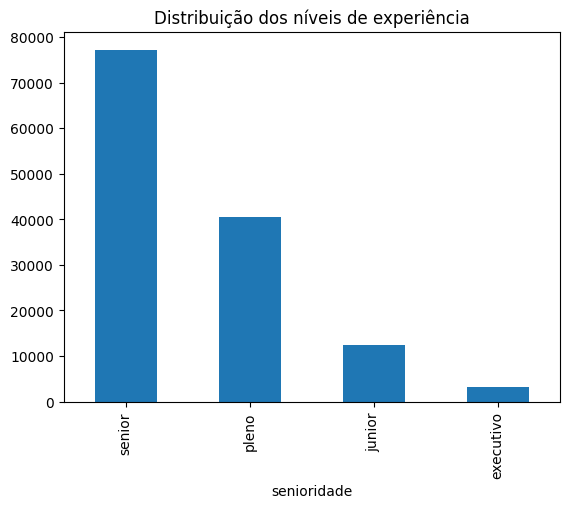

In [62]:
df['senioridade'].value_counts().plot(kind='bar', title='Distribuição dos níveis de experiência')

Criando o primeiro gráfico com Seaborn

In [63]:
import seaborn as sns

Qual é a média salarial por nível de senioridade?

<Axes: xlabel='senioridade', ylabel='usd'>

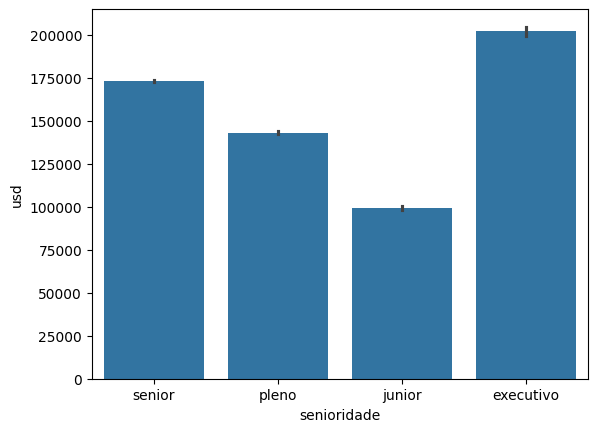

In [64]:
sns.barplot(data=df_limpo, x='senioridade', y='usd', estimator='mean')

Formatando o gráfico com Matplotlib

In [65]:
import matplotlib.pyplot as plt

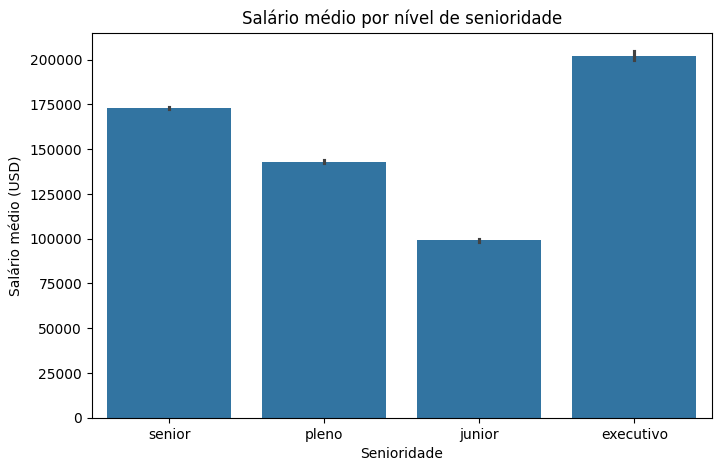

In [66]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', estimator='mean')
plt.title('Salário médio por nível de senioridade')
plt.ylabel('Salário médio (USD)')
plt.xlabel('Senioridade')
plt.show()

Ordenando as categorias do maior para o menor valor:

Dica: Ordenar um gráfico de colunas do maior para o menor valor torna a visualização mais clara e eficiente, pois facilita a comparação entre categorias, destaca rapidamente os dados mais relevantes e melhora a legibilidade geral do gráfico. Essa organização permite que o público identifique com facilidade os maiores e menores valores, perceba padrões e compreenda a mensagem central dos dados com menos esforço visual.

In [67]:
df_limpo.groupby('senioridade')['usd'].mean().sort_values(ascending=False)

,usd
senioridade,
executivo,202027.667813
senior,172850.838301
pleno,143049.887642
junior,99034.963267


In [68]:
ordem = df.groupby('senioridade')['usd'].mean().sort_values(ascending=False).index
ordem

Index(['executivo', 'senior', 'pleno', 'junior'], dtype='object', name='senioridade')

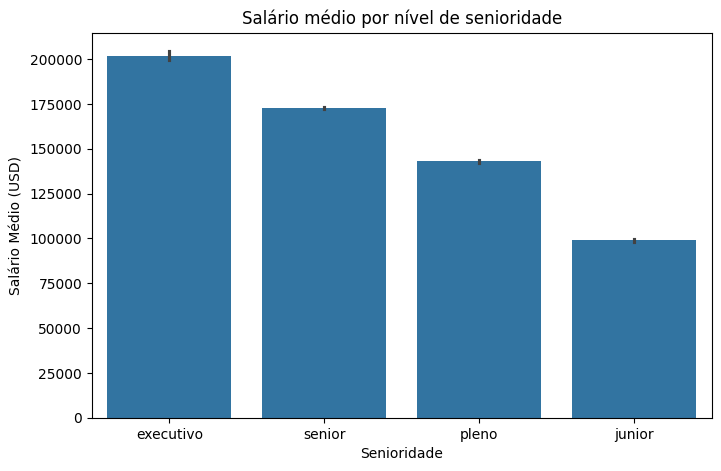

In [69]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senioridade', y='usd', estimator='mean', order=ordem)
plt.title('Salário médio por nível de senioridade')
plt.ylabel('Salário Médio (USD)')
plt.xlabel('Senioridade')
plt.show()

Analisando a distribuição dos salários

Histograma

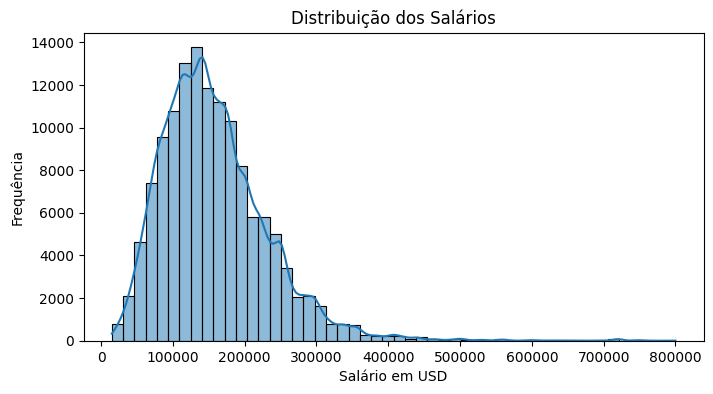

In [70]:
plt.figure(figsize=(8, 4))
sns.histplot(df_limpo['usd'], bins=50, kde=True)
plt.title('Distribuição dos Salários')
plt.xlabel('Salário em USD')
plt.ylabel('Frequência')
plt.show()

Boxplot

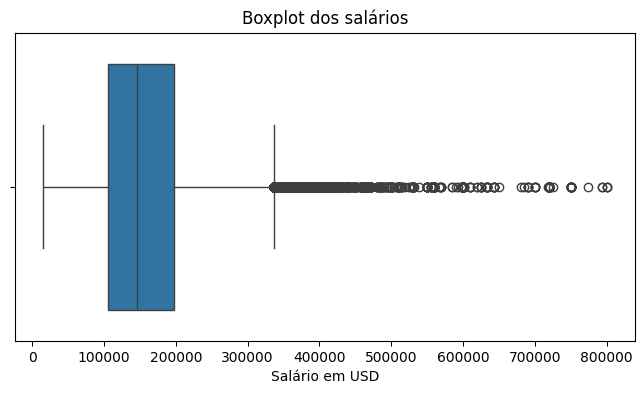

In [71]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_limpo['usd'])
plt.title('Boxplot dos salários')
plt.xlabel('Salário em USD')
plt.show()

Como é a distribuição dos salários de acordo com níveis de senioridade?

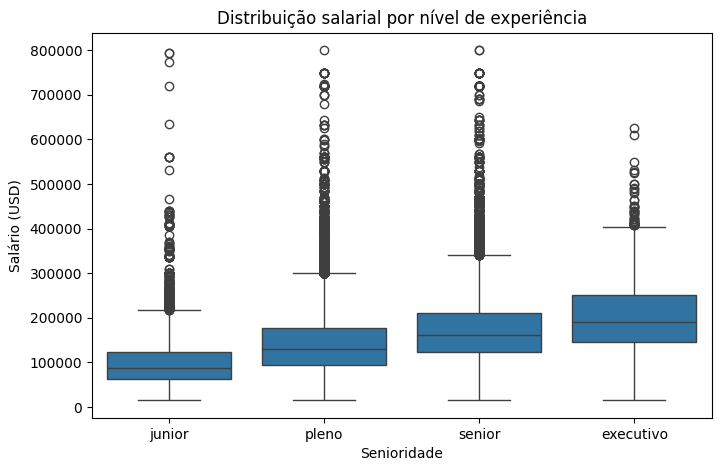

In [72]:
ordem_senioridade = ['junior', 'pleno', 'senior', 'executivo']

plt.figure(figsize=(8, 5))
sns.boxplot(x='senioridade', y='usd', data=df, order=ordem_senioridade)
plt.title('Distribuição salarial por nível de experiência')
plt.xlabel('Senioridade')
plt.ylabel('Salário (USD)')
plt.show()

Se quisermos adicionar uma paleta de cores:

Paletas pré-definidas podem ser encontradas aqui: https://seaborn.pydata.org/tutorial/color_palettes.html

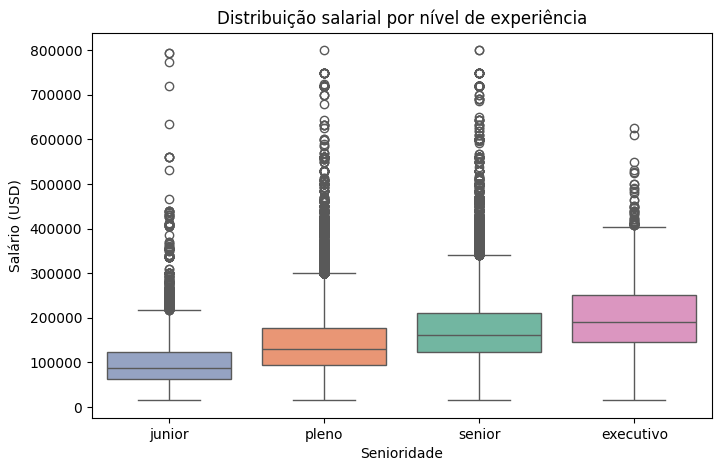

In [73]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='senioridade', y='usd', data=df, order=ordem_senioridade, palette='Set2', hue='senioridade')
plt.title('Distribuição salarial por nível de experiência')
plt.xlabel('Senioridade')
plt.ylabel('Salário (USD)')
plt.show()


Qual país paga o maior média salarial para cientistas de dados especificamente?

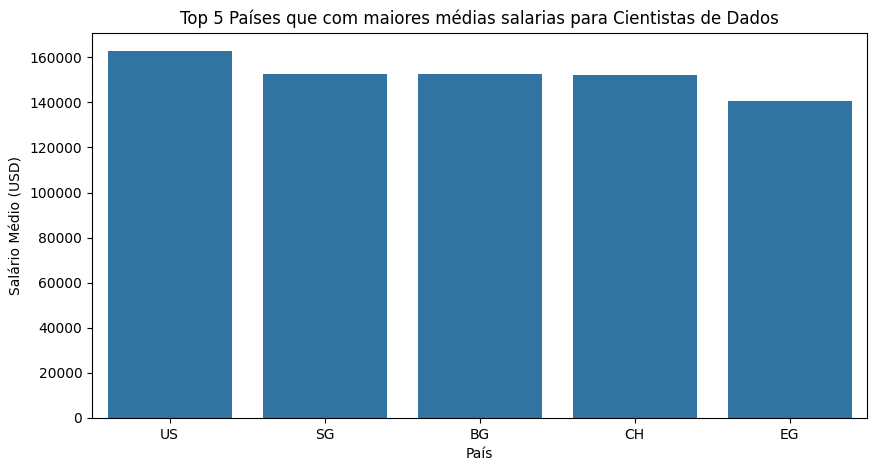

In [74]:
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds = df_ds.groupby('residencia')['usd'].mean().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x='residencia', y='usd', data=media_ds.head(5))
plt.title('Top 5 Países que com maiores médias salarias para Cientistas de Dados')
plt.xlabel('País')
plt.ylabel('Salário Médio (USD)')
plt.show()

US - Estados Unidos

SG - Singapura

BG - Bulgária

CH - Suiça

EG - Egito

Criando gráficos interativos com Plotly

In [75]:
import plotly.express as px

Qual é a média salarial por nível de senioridade?

Refazendo o gráfico na versão interativa

In [76]:
# Calcular média salarial
media_senioridade = df.groupby('senioridade')['usd'].mean().reset_index()

# Criar gráfico
fig = px.bar(media_senioridade, x='senioridade', y='usd',
             title='Salário Médio por Nível de Senioridade',
             labels={'senioridade': 'Senioridade', 'usd': 'Salário Médio (USD)'},
             color='senioridade')

fig.update_layout(xaxis={'categoryorder': 'total descending'})
fig.show()

Qual é a proporção dos tipos de trabalho?

In [77]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(
    remoto_contagem,
    names='tipo_trabalho',
    values='quantidade',
    title='Proporção dos Tipos de Trabalho',
    hole=0.5  # opcional: transforma em donut chart
)
fig.update_traces(textinfo='percent+label')
fig.show()

Qual é o Top 5 de melhores médias salariais por cargo?

In [78]:
top_cargos = df_limpo.groupby('cargo')['usd'].mean().round(2).sort_values(ascending=False).head().reset_index()
top_cargos

,cargo,usd
0,Research Team Lead,450000.0
1,Analytics Engineering Manager,399880.0
2,Data Science Tech Lead,375000.0
3,Applied AI ML Lead,292500.0
4,Head of Applied AI,273875.0


In [79]:
# Gráfico interativo
fig = px.bar(
    top_cargos,
    x='cargo',
    y='usd',
    title='Top 5 cargos com maiores médias salariais',
    labels={'usd': 'Salário médio (USD)', 'cargo': 'Cargo'}
)
fig.update_layout(xaxis_title='Cargo', yaxis_title='Salário médio (USD)')
fig.show()

Mapa do salário médio do Cientista de Dados por país

Instalação de uma biblioteca para converter os códigos de residência, numa sigla que seja possível criar um mapa:

In [80]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 65.2 MB/s eta 0:00:00


In [81]:
import pycountry

# Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
    try:
        return pycountry.countries.get(alpha_2=code).alpha_3
    except:
        return None

# Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3)

# Calcular média salarial por país (ISO-3)
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

# Gerar o mapa
fig = px.choropleth(media_ds_pais,
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn',
                    title='Salário médio de Cientista de Dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})

fig.show()

In [82]:
df_limpo.to_csv('dados-imersao-final.csv', index=False)

Criar o ambiente virtual:
python3 -m venv .venv
Ativar o ambiente virtual em Windows:
.venv\Scripts\Activate
Ativar o ambiente virtual em MAC/LINUX:
source .venv/bin/activate
Criar um arquivo chamado requirements.txt e adicionar os pacotes necessários
pandas==2.2.3
streamlit==1.44.1
plotly==5.24.1
Instalar as bibliotecas necessárias
pip install -r requirements.txt
Criar a Interface do Dashboard com Streamlit

Realizar o deploy do Dashboard no Streamlit Cloud: https://streamlit.io/cloud